<a href="https://colab.research.google.com/github/Sanpie34/Excel-Job-Posting-Analysis/blob/Ye-Shunguang/Job_Posting_Analysis_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

## Goals
1. Investigate top-paying roles and skills in the data science jobs.
2. Use Python to explore a real-live dataset on job postings.
3. For job seekers, use these insights to help find the best job opportunities.

## Questions
1. What are the most demanded skills for the top three most popular data jobs?
2. How are in-demand skills trending for Data Analyst and Data Scientist?
3. How well do jobs and skills pay for Data Analysts and Data Scientists?
4. What is the most optimal skill to learn for Data Analyst and Data Scientist? (High Demand and Paying)


In [155]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import ast

In [156]:
#Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

#Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [157]:
#Filter for US and Non-US Data Analyst and Data Scientist roles
df_DA_nonUS = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] != "United States")]
df_DS_nonUS = df[(df["job_title_short"] == "Data Scientist") & (df["job_country"] != "United States")]

df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")]
df_DS_US = df[(df["job_title_short"] == "Data Scientist") & (df["job_country"] == "United States")]

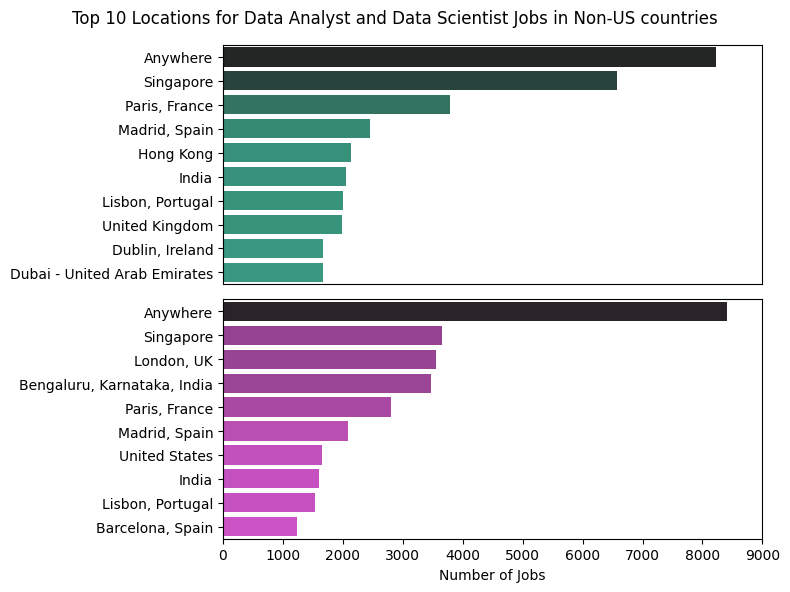

In [158]:
df_DA_plot = df_DA_nonUS["job_location"].value_counts().head(10).to_frame()
df_DS_plot = df_DS_nonUS["job_location"].value_counts().head(10).to_frame()

fig, ax = plt.subplots(2, 1, figsize = (8, 6))
sns.barplot(data = df_DA_plot, x = "count", y = "job_location", ax = ax[0], hue = "count", palette = ("dark:#29A887_r"), legend = False)
fig.suptitle("Top 10 Locations for Data Analyst and Data Scientist Jobs in Non-US countries")
ax[0].get_xaxis().set_visible(False)
ax[0].set_xlim(0, 9000)
ax[0].set_ylabel("")
sns.barplot(data = df_DS_plot, x = "count", y = "job_location", ax = ax[1], hue = "count", palette = ("dark:#E03FD8_r"), legend = False)
ax[1].set_xlim(0, 9000)
ax[1].set_xlabel("Number of Jobs")
ax[1].set_ylabel("")
plt.tight_layout()
plt.show()


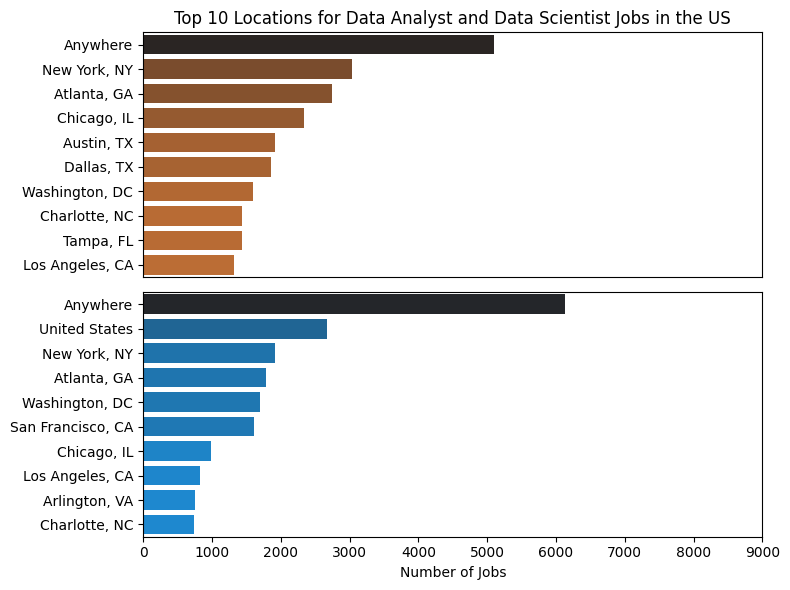

In [159]:
df_DA_US_plot = df_DA_US["job_location"].value_counts().head(10).to_frame()
df_DS_US_plot = df_DS_US["job_location"].value_counts().head(10).to_frame()

fig, ax = plt.subplots(2, 1, figsize = (8, 6))
sns.barplot(data = df_DA_US_plot, x = "count", y = "job_location", ax = ax[0], hue = "count", palette = ("dark:chocolate_r"), legend = False)
ax[0].get_xaxis().set_visible(False)
ax[0].set_xlim(0, 9000)
ax[0].set_title("Top 10 Locations for Data Analyst and Data Scientist Jobs in the US")
ax[0].set_ylabel("")
sns.barplot(data = df_DS_US_plot, x = "count", y = "job_location", ax = ax[1], hue = "count", palette = ("dark:#008EEC_r"), legend = False)
ax[1].set_xlim(0, 9000)
ax[1].set_xlabel("Number of Jobs")
ax[1].set_ylabel("")
plt.tight_layout()
plt.show()

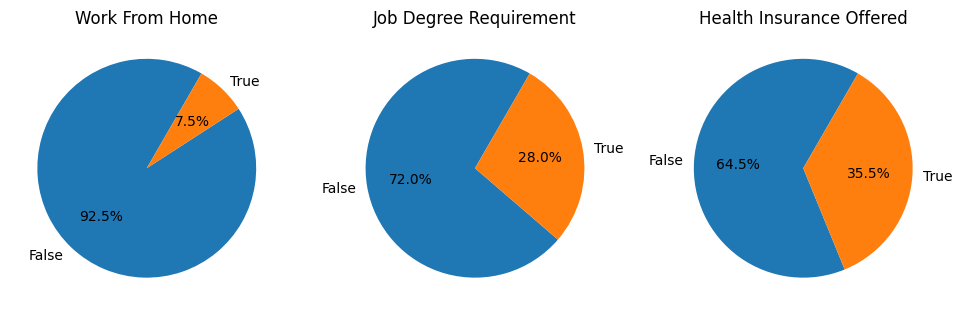

In [160]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

dict_column = {
    "job_work_from_home": "Work From Home",
    "job_no_degree_mention": "Job Degree Requirement",
    "job_health_insurance": "Health Insurance Offered"
    }

for i, (column, title) in enumerate(dict_column.items()):
  ax[i].pie(df_DA_US[column].value_counts(), startangle=60, autopct="%1.1f%%", labels = df_DA_US[column].value_counts().index)
  ax[i].set_title(title)

plt.show()

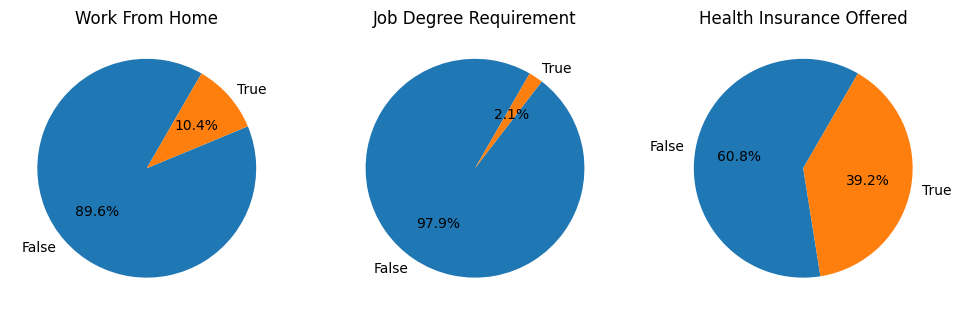

In [161]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

dict_column = {
    "job_work_from_home": "Work From Home",
    "job_no_degree_mention": "Job Degree Requirement",
    "job_health_insurance": "Health Insurance Offered"
    }

for i, (column, title) in enumerate(dict_column.items()):
  ax[i].pie(df_DS_US[column].value_counts(), startangle=60, autopct="%1.1f%%", labels = df_DS_US[column].value_counts().index)
  ax[i].set_title(title)

plt.show()

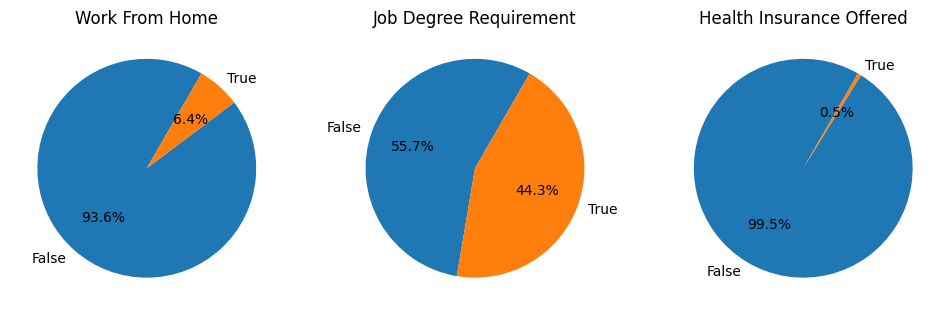

In [162]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

dict_column = {
    "job_work_from_home": "Work From Home",
    "job_no_degree_mention": "Job Degree Requirement",
    "job_health_insurance": "Health Insurance Offered"
    }

for i, (column, title) in enumerate(dict_column.items()):
  ax[i].pie(df_DA_nonUS[column].value_counts(), startangle=60, autopct="%1.1f%%", labels = df_DA_nonUS[column].value_counts().index)
  ax[i].set_title(title)

plt.show()

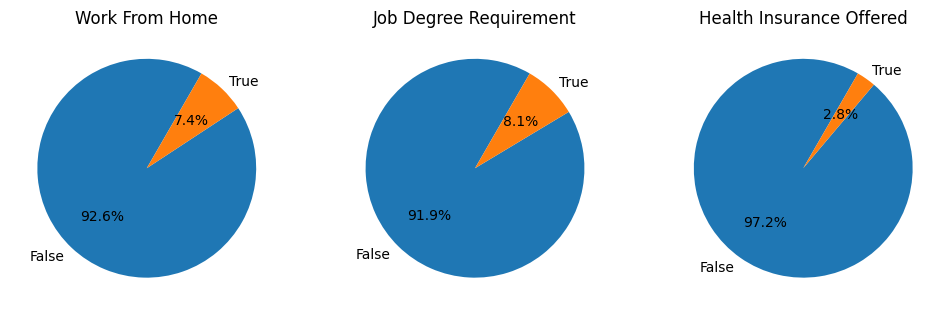

In [163]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

dict_column = {
    "job_work_from_home": "Work From Home",
    "job_no_degree_mention": "Job Degree Requirement",
    "job_health_insurance": "Health Insurance Offered"
    }

for i, (column, title) in enumerate(dict_column.items()):
  ax[i].pie(df_DS_nonUS[column].value_counts(), startangle=60, autopct="%1.1f%%", labels = df_DS_nonUS[column].value_counts().index)
  ax[i].set_title(title)

plt.show()

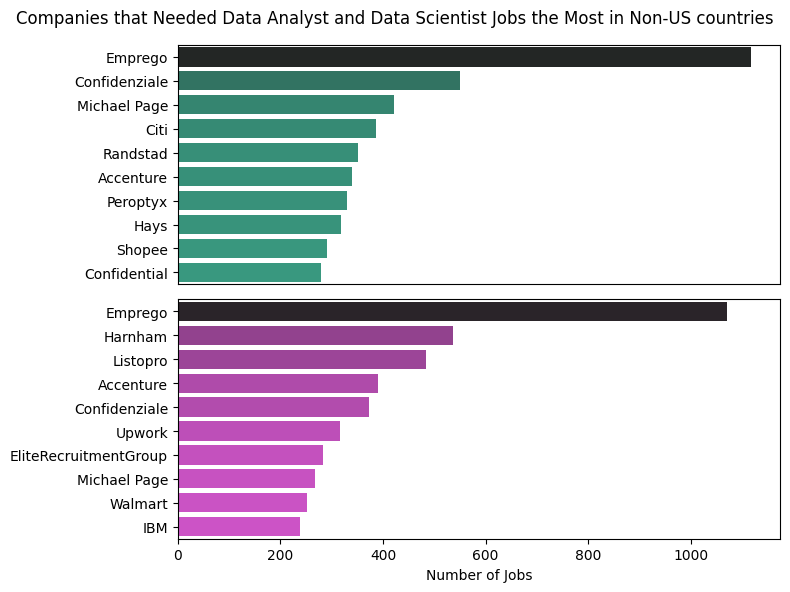

In [164]:
df_DA_plot = df_DA_nonUS["company_name"].value_counts().head(10).to_frame()
df_DS_plot = df_DS_nonUS["company_name"].value_counts().head(10).to_frame()

fig, ax = plt.subplots(2, 1, figsize = (8, 6))
sns.barplot(data = df_DA_plot, x = "count", y = "company_name", ax = ax[0], hue = "count", palette = ("dark:#29A887_r"), legend = False)
ax[0].get_xaxis().set_visible(False)
fig.suptitle("Companies that Needed Data Analyst and Data Scientist Jobs the Most in Non-US countries")
ax[0].set_ylabel("")
sns.barplot(data = df_DS_plot, x = "count", y = "company_name", ax = ax[1], hue = "count", palette = ("dark:#E03FD8_r"), legend = False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_xlabel("Number of Jobs")
ax[1].set_ylabel("")
plt.tight_layout()
plt.show()

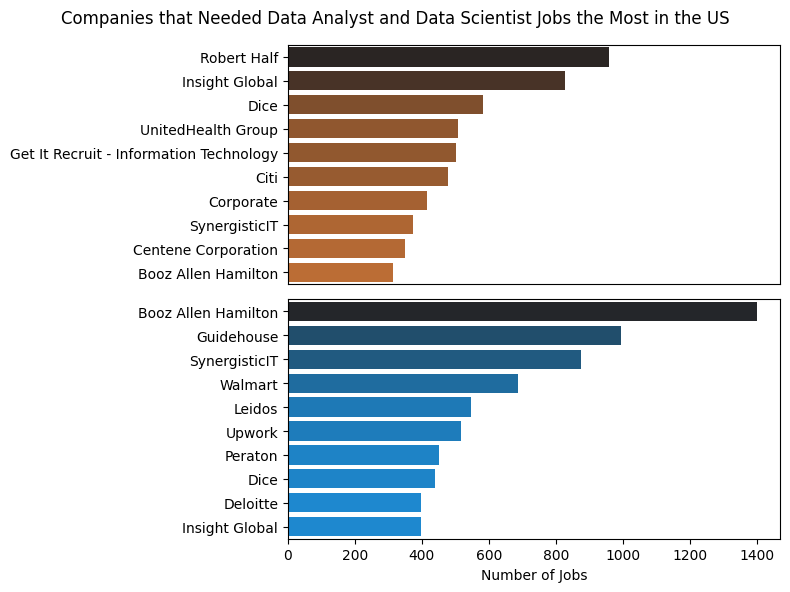

In [165]:
df_DA_US_plot = df_DA_US["company_name"].value_counts().head(10).to_frame()
df_DS_US_plot = df_DS_US["company_name"].value_counts().head(10).to_frame()

fig, ax = plt.subplots(2, 1, figsize = (8, 6))
sns.barplot(data = df_DA_US_plot, x = "count", y = "company_name", ax = ax[0], hue = "count", palette = ("dark:chocolate_r"), legend = False)
ax[0].get_xaxis().set_visible(False)
fig.suptitle("Companies that Needed Data Analyst and Data Scientist Jobs the Most in the US")
ax[0].set_ylabel("")
sns.barplot(data = df_DS_US_plot, x = "count", y = "company_name", ax = ax[1], hue = "count", palette = ("dark:#008EEC_r"), legend = False)
ax[0].set_xlim(ax[1].get_xlim())
ax[1].set_xlabel("Number of Jobs")
ax[1].set_ylabel("")
plt.tight_layout()
plt.show()

# Skill Demand

## 1. What are the most demanded skills for the top three data jobs?

In [166]:
#Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

#Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [167]:
df_US = df[df["job_country"] == "United States"]
df_nonUS = df[df["job_country"] != "United States"]

In [168]:
df_skills_US = df_US.explode("job_skills")
df_skills_nonUS = df_nonUS.explode("job_skills")

df_skills_count_US = df_skills_US.groupby(["job_skills", "job_title_short"]).size().reset_index(name="skill_count").sort_values(by = "skill_count", ascending = False)
df_skills_count_nonUS = df_skills_nonUS.groupby(["job_skills", "job_title_short"]).size().reset_index(name="skill_count").sort_values(by = "skill_count", ascending = False)


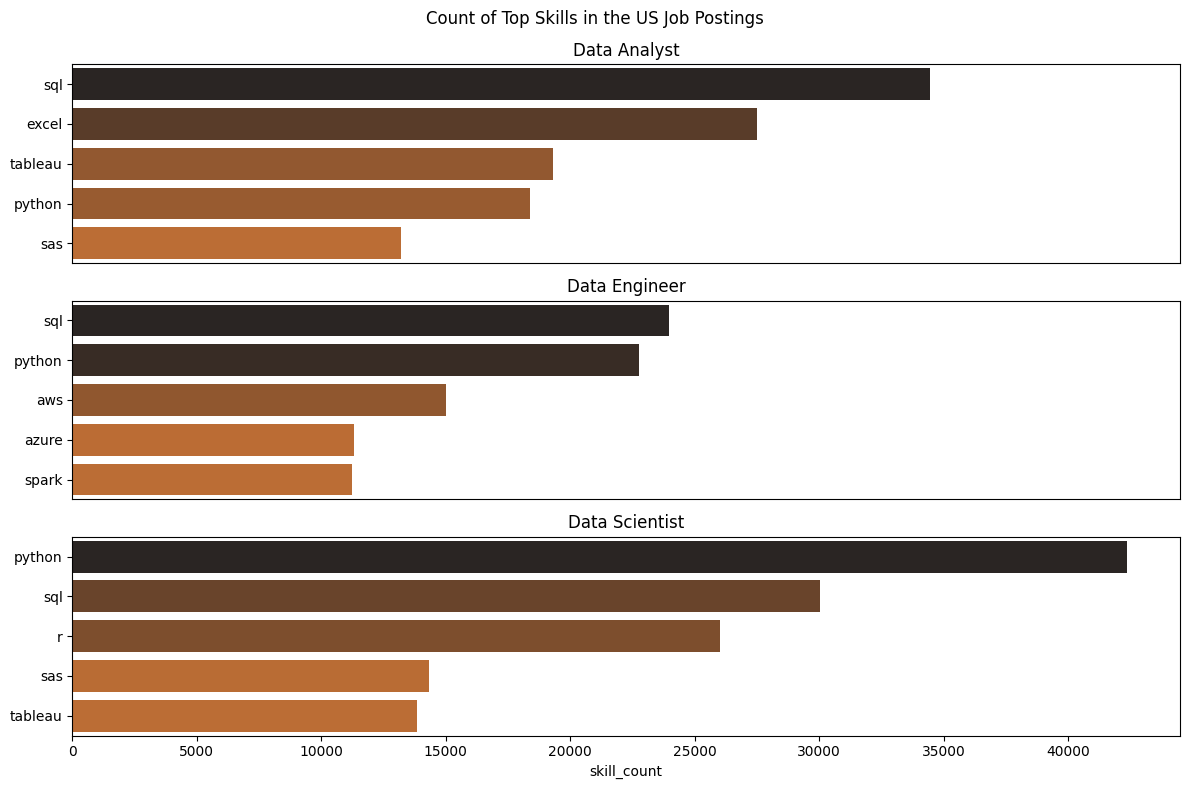

In [169]:
job_titles = sorted(df_skills_count_US["job_title_short"].unique().tolist()[:3])
fig, ax = plt.subplots(len(job_titles), figsize=(12, 8))
for i, job_titles in enumerate(job_titles):
  df_US_plot = df_skills_count_US[df_skills_count_US['job_title_short'] == job_titles].head(5)
  sns.barplot(data = df_US_plot, x = "skill_count", y = "job_skills", ax = ax[i], hue = "skill_count", palette = ("dark:chocolate_r"), legend = False)
  ax[i].set_title(f"{job_titles}")
  ax[i].set_ylabel("")
ax[0].get_xaxis().set_visible(False)
ax[1].get_xaxis().set_visible(False)
ax[0].set_xlim(ax[2].get_xlim())
ax[1].set_xlim(ax[2].get_xlim())
fig.suptitle("Count of Top Skills in the US Job Postings")
plt.tight_layout()
plt.show()



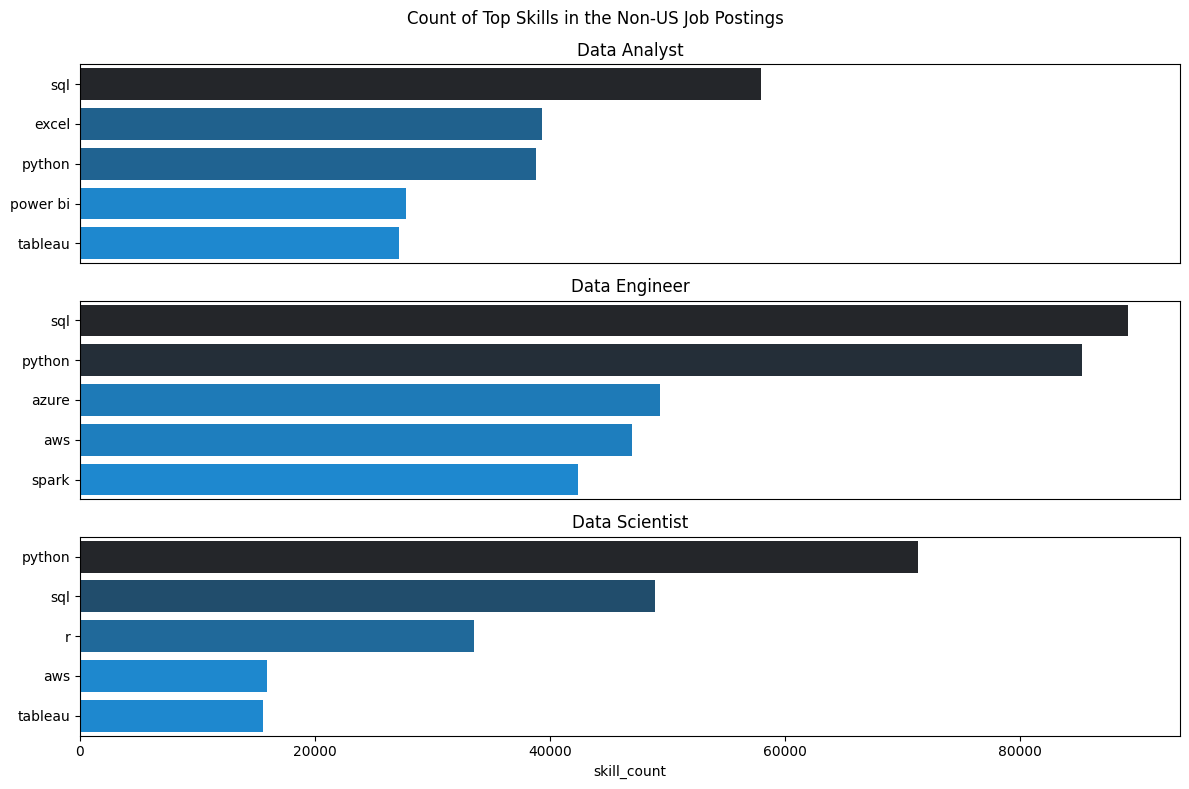

In [170]:
job_titles = sorted(df_skills_count_nonUS["job_title_short"].unique().tolist()[:3])
fig, ax = plt.subplots(len(job_titles), figsize=(12, 8))
for i, job_titles in enumerate(job_titles):
  df_nonUS_plot = df_skills_count_nonUS[df_skills_count_nonUS['job_title_short'] == job_titles].head(5)
  sns.barplot(data = df_nonUS_plot, x = "skill_count", y = "job_skills", ax = ax[i], hue = "skill_count", palette = ("dark:#008EEC_r"), legend = False)
  ax[i].set_title(f"{job_titles}")
  ax[i].set_ylabel("")
ax[0].get_xaxis().set_visible(False)
ax[1].get_xaxis().set_visible(False)
ax[0].set_xlim(ax[1].get_xlim())
ax[2].set_xlim(ax[1].get_xlim())
fig.suptitle("Count of Top Skills in the Non-US Job Postings")
plt.tight_layout()
plt.show()


In [171]:
df_job_title_count_US = df_US["job_title_short"].value_counts().reset_index(name = "jobs_total")
df_job_title_count_nonUS = df_nonUS["job_title_short"].value_counts().reset_index(name = "jobs_total")

In [172]:
df_skills_percent_US = pd.merge(df_skills_count_US, df_job_title_count_US, how = "left", on = "job_title_short")
df_skills_percent_US["skill_percent"] = 100 * df_skills_percent_US["skill_count"] / df_skills_percent_US["jobs_total"]
df_skills_percent_nonUS = pd.merge(df_skills_count_nonUS, df_job_title_count_nonUS, how = "left", on = "job_title_short")
df_skills_percent_nonUS["skill_percent"] = 100 * df_skills_percent_nonUS["skill_count"] / df_skills_percent_nonUS["jobs_total"]

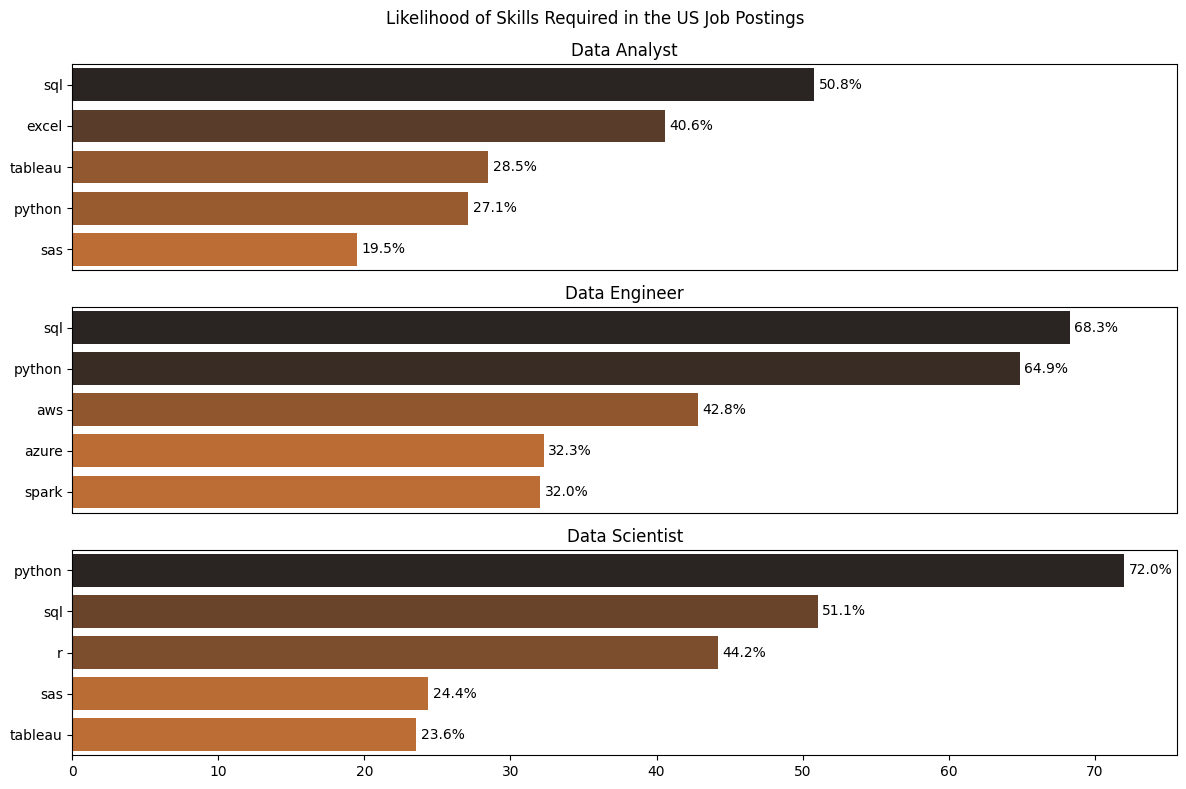

In [173]:
#use sns.set_theme(style="ticks") if needed
job_titles = sorted(df_skills_percent_US["job_title_short"].unique().tolist()[:3])
fig, ax = plt.subplots(len(job_titles), figsize=(12, 8))
for i, job_titles in enumerate(job_titles):
  df_US_plot = df_skills_percent_US[df_skills_percent_US['job_title_short'] == job_titles].head(5)
  sns.barplot(data = df_US_plot, x = "skill_percent", y = "job_skills", ax = ax[i], hue = "skill_percent", palette = ("dark:chocolate_r"), legend = False)
  ax[i].set_title(f"{job_titles}")
  ax[i].set_ylabel("")
  ax[i].set_xlabel("")
  for n, v in enumerate(df_US_plot["job_skills"]):
    percent_value = df_US_plot["skill_percent"].iloc[n]
    ax[i].text(percent_value + 0.3, n, f'{percent_value:.1f}%', va = "center")
  if i != 2:
    ax[i].get_xaxis().set_visible(False)

ax[0].set_xlim(ax[2].get_xlim())
ax[1].set_xlim(ax[2].get_xlim())
fig.suptitle("Likelihood of Skills Required in the US Job Postings")
plt.tight_layout()
plt.show()

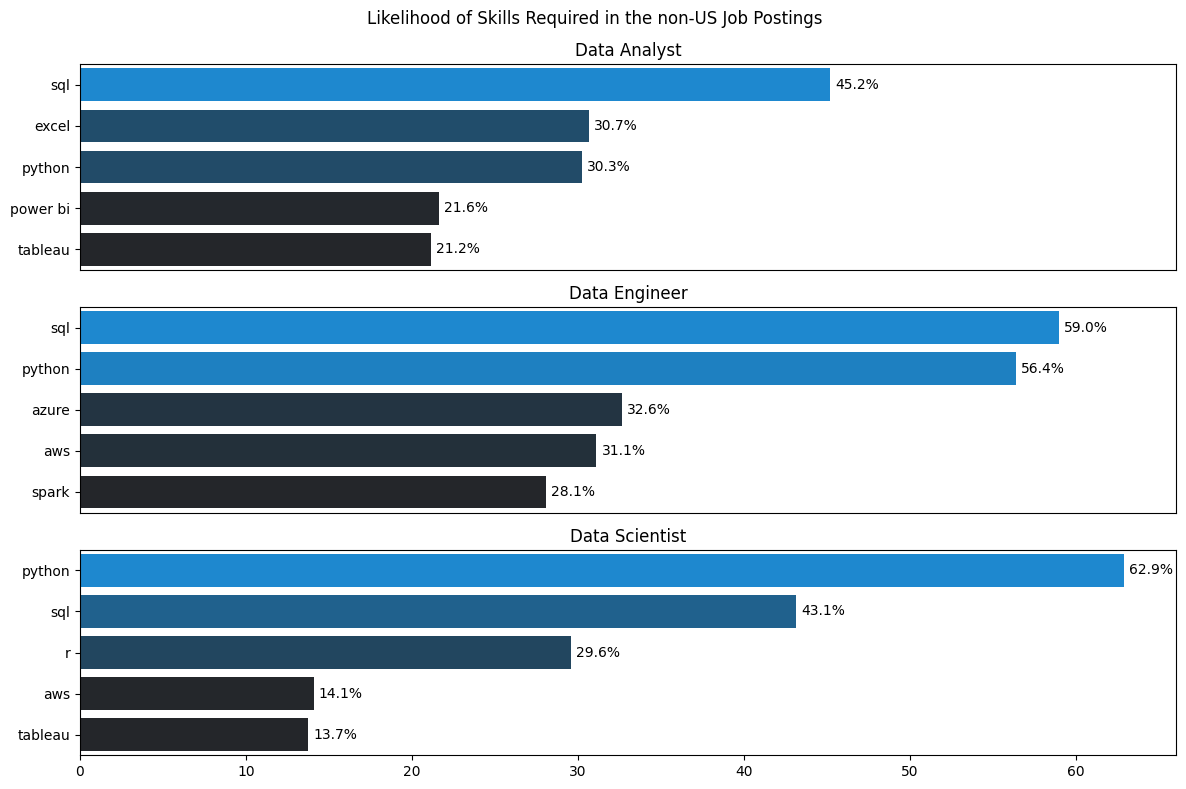

In [174]:
job_titles = sorted(df_skills_percent_nonUS["job_title_short"].unique().tolist()[:3])
fig, ax = plt.subplots(len(job_titles), figsize=(12, 8))
for i, job_titles in enumerate(job_titles):
  df_nonUS_plot = df_skills_percent_nonUS[df_skills_percent_nonUS['job_title_short'] == job_titles].head(5)
  sns.barplot(data = df_nonUS_plot, x = "skill_percent", y = "job_skills", ax = ax[i], hue = "skill_percent", palette = ("dark:#008EEC"), legend = False)
  ax[i].set_title(f"{job_titles}")
  ax[i].set_ylabel("")
  ax[i].set_xlabel("")
  for n, v in enumerate(df_nonUS_plot["job_skills"]):
    percent_value = df_nonUS_plot["skill_percent"].iloc[n]
    ax[i].text(percent_value + 0.3, n, f'{percent_value:.1f}%', va = "center")
  if i != 2:
    ax[i].get_xaxis().set_visible(False)

ax[0].set_xlim(ax[2].get_xlim())
ax[1].set_xlim(ax[2].get_xlim())
fig.suptitle("Likelihood of Skills Required in the non-US Job Postings")
plt.tight_layout()
plt.show()

# Skills Trend

## 2. How are in-demand skills trending for Data Analyst and Data Scientist?

In [175]:
#Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

#Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [176]:
#Filter for Non-US Data Analyst and Data Scientist roles
df_DA_nonUS = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] != "United States")].copy()
df_DS_nonUS = df[(df["job_title_short"] == "Data Scientist") & (df["job_country"] != "United States")].copy()

df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()
df_DS_US = df[(df["job_title_short"] == "Data Scientist") & (df["job_country"] == "United States")].copy()

In [177]:
df_DA_US["job_posted_month_no"] = df_DA_US["job_posted_date"].dt.month
df_DA_nonUS["job_posted_month_no"] = df_DA_nonUS["job_posted_date"].dt.month

df_DS_US["job_posted_month_no"] = df_DS_US["job_posted_date"].dt.month
df_DS_nonUS["job_posted_month_no"] = df_DS_nonUS["job_posted_date"].dt.month

In [178]:
df_DA_US_explode = df_DA_US.explode("job_skills")
df_DA_nonUS_explode = df_DA_nonUS.explode("job_skills")

df_DS_US_explode = df_DS_US.explode("job_skills")
df_DS_nonUS_explode = df_DS_nonUS.explode("job_skills")

In [179]:
df_DA_US_pivot = df_DA_US_explode.pivot_table(index="job_posted_month_no", columns = "job_skills", aggfunc = "size", fill_value = 0)
#df_DA_nonUS_pivot = df_DA_nonUS_explode.pivot_table(index="job_posted_month_no", columns = "job_skills", aggfunc = "size", fill_value = 0)
df_DS_US_pivot = df_DS_US_explode.pivot_table(index="job_posted_month_no", columns = "job_skills", aggfunc = "size", fill_value = 0)
#df_DS_nonUS_pivot = df_DS_nonUS_explode.pivot_table(index="job_posted_month_no", columns = "job_skills", aggfunc = "size", fill_value = 0)

df_DA_US_pivot.loc["Total"] = df_DA_US_pivot.sum()
#df_DA_nonUS_pivot.loc["Total"] = df_DA_nonUS_pivot.sum()
df_DS_US_pivot.loc["Total"] = df_DS_US_pivot.sum()
#df_DS_nonUS_pivot.loc["Total"] = df_DS_nonUS_pivot.sum()

df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc["Total"].sort_values(ascending = False).index]
#df_DA_nonUS_pivot = df_DA_nonUS_pivot[df_DA_US_pivot.loc["Total"].sort_values(ascending = False).index]
df_DS_US_pivot = df_DS_US_pivot[df_DS_US_pivot.loc["Total"].sort_values(ascending = False).index]
#df_DS_nonUS_pivot = df_DS_nonUS_pivot[df_DS_nonUS_pivot.loc["Total"].sort_values(ascending = False).index]

df_DA_US_pivot = df_DA_US_pivot.drop("Total")
#df_DA_nonUS_pivot = df_DA_nonUS_pivot.drop("Total")
df_DS_US_pivot = df_DS_US_pivot.drop("Total")
#df_DS_nonUS_pivot = df_DS_nonUS_pivot.drop("Total")

In [180]:
DA_totals = df_DA_US.groupby("job_posted_month_no").size()
DS_totals = df_DS_US.groupby("job_posted_month_no").size()

In [181]:
df_DA_US_percent = df_DA_US_pivot.div(DA_totals/100, axis = 0)
df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent["job_posted_month"] = df_DA_US_percent["job_posted_month_no"].apply(lambda x: pd.to_datetime(str(x), format = "%m").strftime("%b"))
df_DA_US_percent = df_DA_US_percent.set_index("job_posted_month")
df_DA_US_percent = df_DA_US_percent.drop(columns = "job_posted_month_no")


df_DS_US_percent = df_DS_US_pivot.div(DS_totals/100, axis = 0)
df_DS_US_percent = df_DS_US_percent.reset_index()
df_DS_US_percent["job_posted_month"] = df_DS_US_percent["job_posted_month_no"].apply(lambda x: pd.to_datetime(str(x), format = "%m").strftime("%b"))
df_DS_US_percent = df_DS_US_percent.set_index("job_posted_month")
df_DS_US_percent = df_DS_US_percent.drop(columns = "job_posted_month_no")


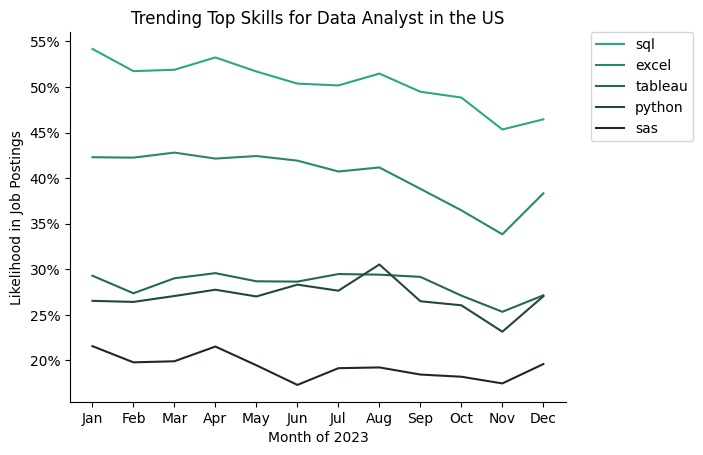

In [182]:
df_DA_plot = df_DA_US_percent.iloc[:, :5]

sns.lineplot(data = df_DA_plot, dashes = False, palette = ("dark:#29A887_r"))
sns.despine()

plt.title("Trending Top Skills for Data Analyst in the US")
plt.xlabel("Month of 2023")
plt.ylabel("Likelihood in Job Postings")
plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0.)
#for i in range(5):
#  plt.text(11.2, df_DA_plot.iloc[1, i], df_DA_plot.columns[i])
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals = 0))
plt.show()


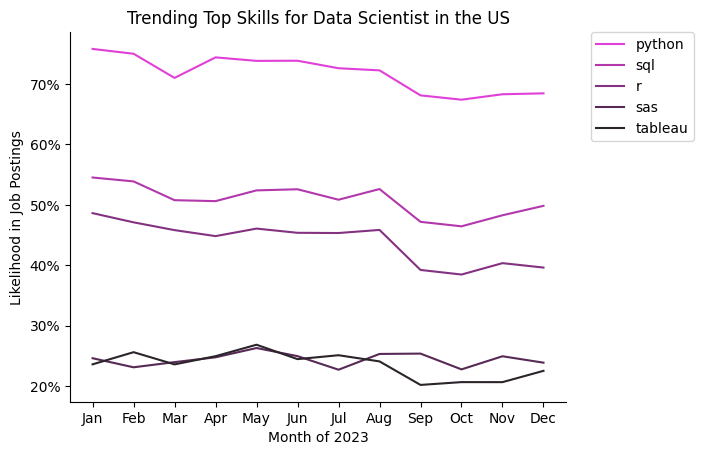

In [183]:
df_DS_plot = df_DS_US_percent.iloc[:, :5]

sns.lineplot(data = df_DS_plot, dashes = False, palette = ("dark:#E03FD8_r"))
sns.despine()

plt.title("Trending Top Skills for Data Scientist in the US")
plt.xlabel("Month of 2023")
plt.ylabel("Likelihood in Job Postings")
plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0.)
#for i in range(5):
#  plt.text(11.2, df_DS_plot.iloc[1, i], df_DS_plot.columns[i])
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals = 0))
plt.show()

# Salary Analysis

## 3. How well do jobs and skills pay for Data Analysts and Data Scientist?

In [184]:
#Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

#Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [185]:
df_US = df[df["job_country"] == "United States"].dropna(subset = ["salary_year_avg"])
df_nonUS = df[df["job_country"] != "United States"].dropna(subset = ["salary_year_avg"])

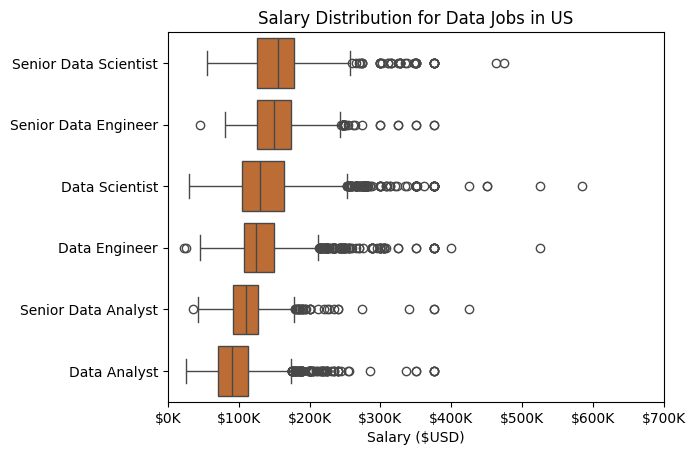

In [186]:
job_titles_US = df_US["job_title_short"].value_counts().index[:6].tolist()

df_US_top6 = df_US[df_US["job_title_short"].isin(job_titles_US)]
job_order = df_US_top6.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending = False).index

sns.boxplot(data = df_US_top6, x = "salary_year_avg", y = "job_title_short", orient = "h", color = "chocolate", order = job_order)
plt.title("Salary Distribution for Data Jobs in US")
plt.xlabel("Salary ($USD)")
plt.ylabel("")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))
plt.xlim(0, 700000)
plt.show()

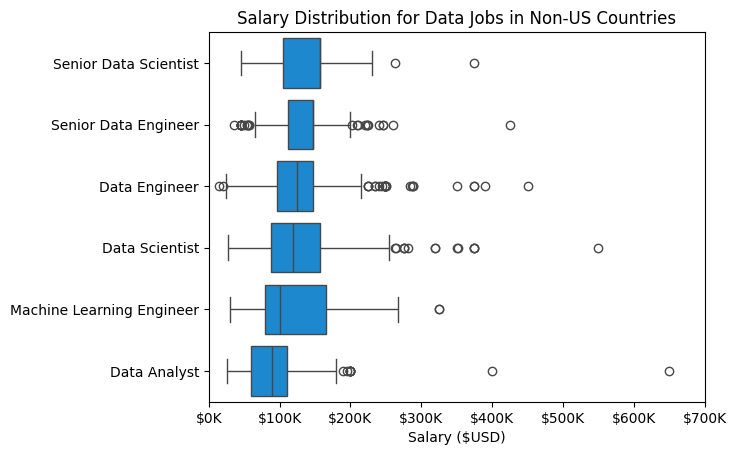

In [187]:
job_titles_nonUS = df_nonUS["job_title_short"].value_counts().index[:6].tolist()

df_nonUS_top6 = df_nonUS[df_nonUS["job_title_short"].isin(job_titles_nonUS)]
job_order = df_nonUS_top6.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending = False).index

sns.boxplot(data = df_nonUS_top6, x = "salary_year_avg", y = "job_title_short", orient = "h", color = "#008EEC", order = job_order)
plt.title("Salary Distribution for Data Jobs in Non-US Countries")
plt.xlabel("Salary ($USD)")
plt.ylabel("")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))
plt.xlim(0, 700000)
plt.show()

In [188]:
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()
df_DA_US = df_DA_US.dropna(subset = ["salary_year_avg"])
df_DS_US = df[(df["job_title_short"] == "Data Scientist") & (df["job_country"] == "United States")].copy()
df_DS_US = df_DS_US.dropna(subset = ["salary_year_avg"])

In [189]:
df_DA_US = df_DA_US.explode("job_skills")
df_DS_US = df_DS_US.explode("job_skills")

In [190]:
df_DA_US_group = df_DA_US.groupby("job_skills")["salary_year_avg"].agg(["count", "median"])
df_DA_top_pay_US = df_DA_US_group.sort_values(by = "median", ascending = False).head(10)
df_DA_skills_US = df_DA_US_group.sort_values(by="count", ascending=False).head(10).sort_values(by = "median", ascending = False).head(10)

df_DS_US_group = df_DS_US.groupby("job_skills")["salary_year_avg"].agg(["count", "median"])
df_DS_top_pay_US = df_DS_US_group.sort_values(by = "median", ascending = False).head(10)
df_DS_skill_US = df_DS_US_group.sort_values(by="count", ascending=False).head(10).sort_values(by = "median", ascending = False).head(10)


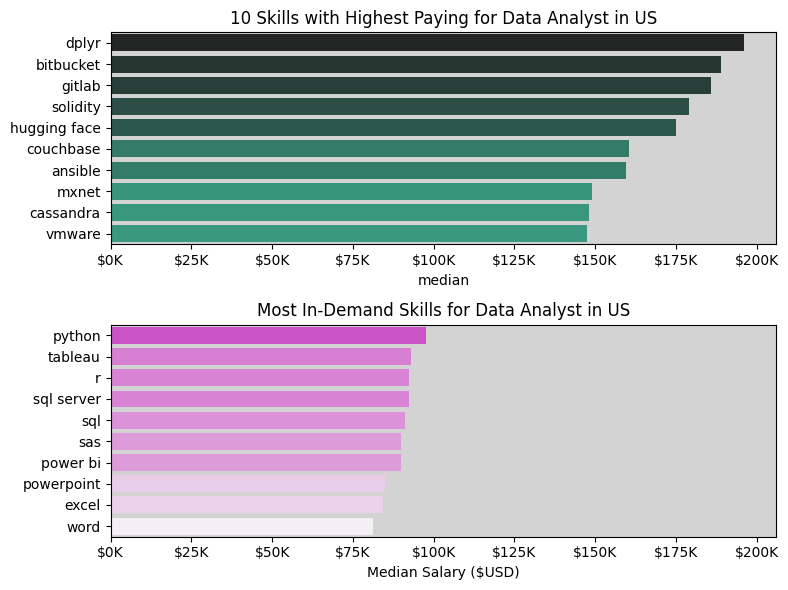

In [191]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Set figure and axes background colors
fig.set_facecolor('white') # Set figure background color
ax[0].set_facecolor('lightgray') # Set subplot 0 background color
ax[1].set_facecolor('lightgray') # Set subplot 1 background color

sns.barplot(data = df_DA_top_pay_US, x = "median", y = df_DA_top_pay_US.index, ax = ax[0], hue = "median", palette = "dark:#29A887_r")
ax[0].legend().remove()

ax[0].set_title("10 Skills with Highest Paying for Data Analyst in US")
ax[0].set_ylabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))


sns.barplot(data = df_DA_skills_US, x = "median", y = df_DA_skills_US.index, ax = ax[1], hue = "median", palette = "light:#E03FD8")
ax[1].legend().remove()

ax[1].set_title("Most In-Demand Skills for Data Analyst in US")
ax[1].set_xlabel("Median Salary ($USD)")
ax[1].set_ylabel("")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))
plt.tight_layout()
plt.show()

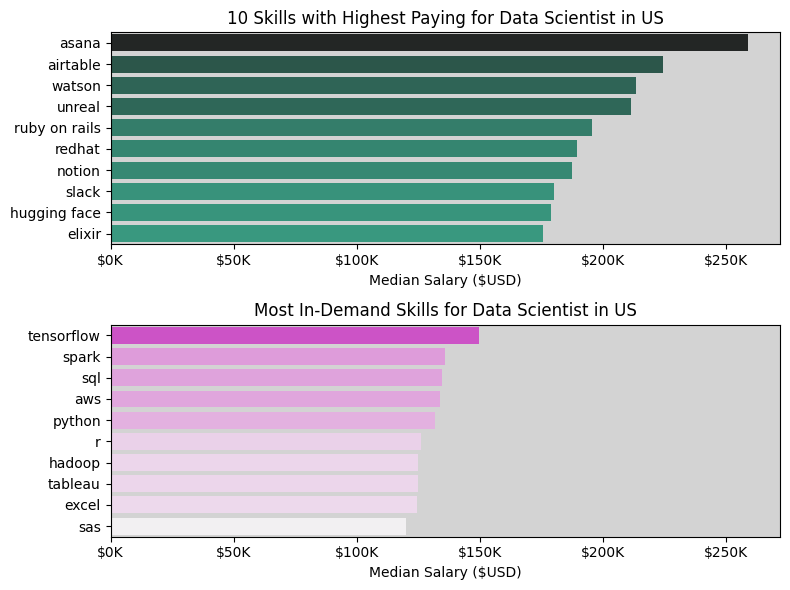

In [192]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Set figure and axes background colors
fig.set_facecolor('white') # Set figure background color
ax[0].set_facecolor('lightgray') # Set subplot 0 background color
ax[1].set_facecolor('lightgray') # Set subplot 1 background color

sns.barplot(data = df_DS_top_pay_US, x = "median", y = df_DS_top_pay_US.index, ax = ax[0], hue = "median", palette = "dark:#29A887_r")
ax[0].legend().remove()

ax[0].set_title("10 Skills with Highest Paying for Data Scientist in US")
ax[0].set_xlabel("Median Salary ($USD)")
ax[0].set_ylabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))


sns.barplot(data = df_DS_skill_US, x = "median", y = df_DS_skill_US.index, ax = ax[1], hue = "median", palette = "light:#E03FD8")
ax[1].legend().remove()

ax[1].set_title("Most In-Demand Skills for Data Scientist in US")
ax[1].set_xlabel("Median Salary ($USD)")
ax[1].set_ylabel("")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))
plt.tight_layout()
plt.show()

In [193]:
df_DA_nonUS = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] != "United States")].copy()
df_DA_nonUS = df_DA_nonUS.dropna(subset = ["salary_year_avg"])
df_DS_nonUS = df[(df["job_title_short"] == "Data Scientist") & (df["job_country"] != "United States")].copy()
df_DS_nonUS = df_DS_nonUS.dropna(subset = ["salary_year_avg"])

df_DA_nonUS = df_DA_nonUS.explode("job_skills")
df_DS_nonUS = df_DS_nonUS.explode("job_skills")

df_DA_nonUS_group = df_DA_nonUS.groupby("job_skills")["salary_year_avg"].agg(["count", "median"])
df_DA_top_pay_nonUS = df_DA_nonUS_group.sort_values(by = "median", ascending = False).head(10)
df_DA_skills_nonUS = df_DA_nonUS_group.sort_values(by="count", ascending=False).head(10).sort_values(by = "median", ascending = False).head(10)

df_DS_nonUS_group = df_DS_nonUS.groupby("job_skills")["salary_year_avg"].agg(["count", "median"])
df_DS_top_pay_nonUS = df_DS_nonUS_group.sort_values(by = "median", ascending = False).head(10)
df_DS_skill_nonUS = df_DS_nonUS_group.sort_values(by="count", ascending=False).head(10).sort_values(by = "median", ascending = False).head(10)

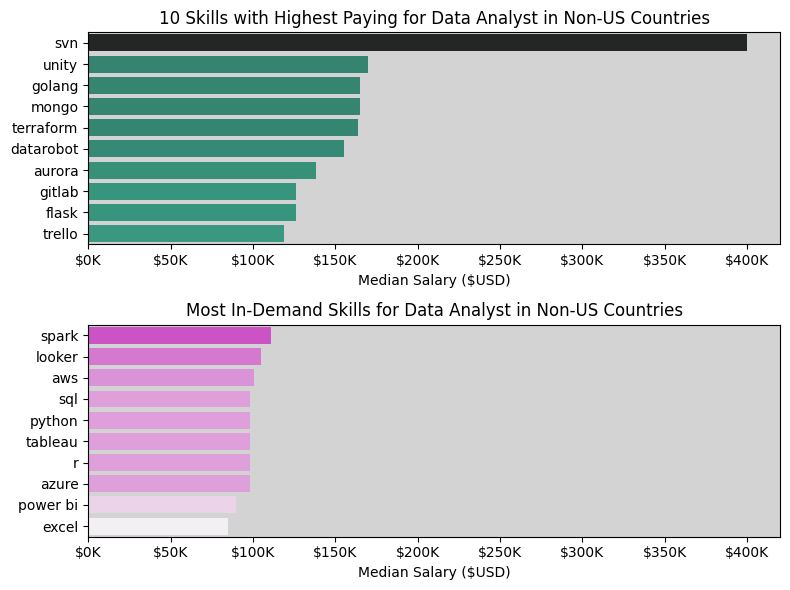

In [194]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Set figure and axes background colors
fig.set_facecolor('white') # Set figure background color
ax[0].set_facecolor('lightgray') # Set subplot 0 background color
ax[1].set_facecolor('lightgray') # Set subplot 1 background color

sns.barplot(data = df_DA_top_pay_nonUS, x = "median", y = df_DA_top_pay_nonUS.index, ax = ax[0], hue = "median", palette = "dark:#29A887_r")
ax[0].legend().remove()

ax[0].set_title("10 Skills with Highest Paying for Data Analyst in Non-US Countries")
ax[0].set_xlabel("Median Salary ($USD)")
ax[0].set_ylabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))


sns.barplot(data = df_DA_skills_nonUS, x = "median", y = df_DA_skills_nonUS.index, ax = ax[1], hue = "median", palette = "light:#E03FD8")
ax[1].legend().remove()

ax[1].set_title("Most In-Demand Skills for Data Analyst in Non-US Countries")
ax[1].set_xlabel("Median Salary ($USD)")
ax[1].set_ylabel("")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))
plt.tight_layout()
plt.show()

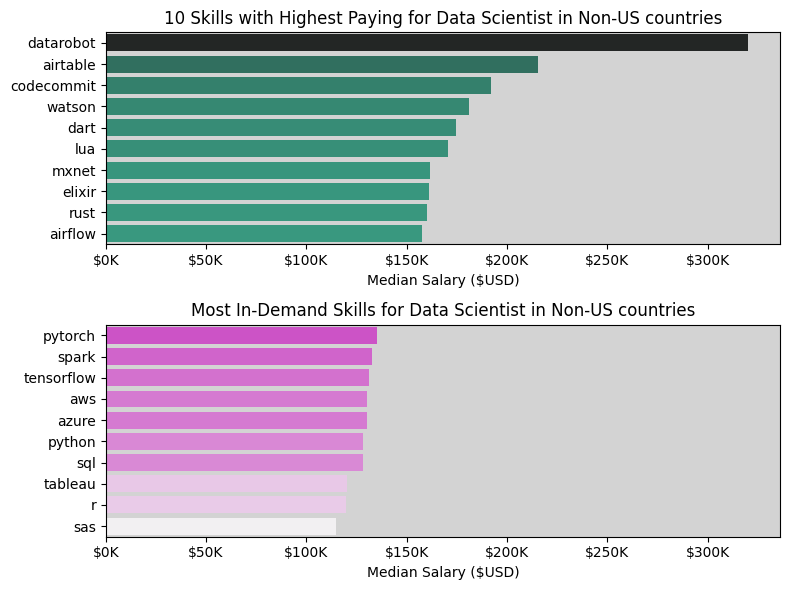

In [195]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Set figure and axes background colors
fig.set_facecolor('white') # Set figure background color
ax[0].set_facecolor('lightgray') # Set subplot 0 background color
ax[1].set_facecolor('lightgray') # Set subplot 1 background color

sns.barplot(data = df_DS_top_pay_nonUS, x = "median", y = df_DS_top_pay_nonUS.index, ax = ax[0], hue = "median", palette = "dark:#29A887_r")
ax[0].legend().remove()

ax[0].set_title("10 Skills with Highest Paying for Data Scientist in Non-US countries")
ax[0].set_xlabel("Median Salary ($USD)")
ax[0].set_ylabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))


sns.barplot(data = df_DS_skill_nonUS, x = "median", y = df_DS_skill_nonUS.index, ax = ax[1], hue = "median", palette = "light:#E03FD8")
ax[1].legend().remove()

ax[1].set_title("Most In-Demand Skills for Data Scientist in Non-US countries")
ax[1].set_xlabel("Median Salary ($USD)")
ax[1].set_ylabel("")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x/1000)}K"))
plt.tight_layout()
plt.show()

# Optimal Skills

## 4. What is the most optimal skill to learn for Data Analyst and Data Scientist?

In [196]:
#Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

#Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [197]:
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()
df_DA_US = df_DA_US.dropna(subset = ["salary_year_avg"])
df_DS_US = df[(df["job_title_short"] == "Data Scientist") & (df["job_country"] == "United States")].copy()
df_DS_US = df_DS_US.dropna(subset = ["salary_year_avg"])

df_DA_US_exploded = df_DA_US.explode("job_skills")
df_DS_US_exploded = df_DS_US.explode("job_skills")

In [198]:
df_DA_skills_US = df_DA_US_exploded.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by = "median", ascending = False)
df_DA_skills_US = df_DA_skills_US.rename(columns={"count": "skill_count", "median": "median_salary"})
DA_job_count_US = len(df_DA_US)
df_DA_skills_US["skill_percent"] = df_DA_skills_US["skill_count"] / DA_job_count_US * 100
skill_percent = 5
df_DA_skills_high_demand_US = df_DA_skills_US[df_DA_skills_US["skill_percent"] > skill_percent]

df_DS_skills_US = df_DS_US_exploded.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by = "median", ascending = False)
df_DS_skills_US = df_DS_skills_US.rename(columns={"count": "skill_count", "median": "median_salary"})
DS_job_count_US = len(df_DS_US)
df_DS_skills_US["skill_percent"] = df_DS_skills_US["skill_count"] / DS_job_count_US * 100
#skill_percent = 5
df_DS_skills_high_demand_US = df_DS_skills_US[df_DS_skills_US["skill_percent"] > skill_percent]


In [199]:
#!pip install adjustText

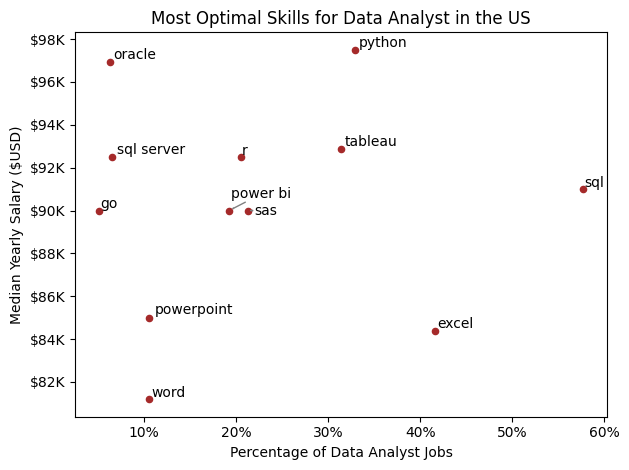

In [200]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

df_DA_skills_high_demand_US.plot(kind="scatter", x = "skill_percent", y = "median_salary", color = "brown")

texts = []
for i, txt in enumerate(df_DA_skills_high_demand_US.index):
  texts.append(plt.text(df_DA_skills_high_demand_US["skill_percent"].iloc[i], df_DA_skills_high_demand_US["median_salary"].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray'))

plt.title("Most Optimal Skills for Data Analyst in the US")
plt.xlabel("Percentage of Data Analyst Jobs")
plt.ylabel("Median Yearly Salary ($USD)")


plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y/1000)}K"))
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals = 0))

plt.tight_layout()
plt.show()

In [201]:
df_technology = df["job_type_skills"].copy()
df_technology = df_technology.drop_duplicates()
df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
  row_dict = ast.literal_eval(row)
  for key, value in row_dict.items():
    if key in technology_dict:
      technology_dict[key] += value
    else:
      technology_dict[key] = value

for key, value in technology_dict.items():
  technology_dict[key] = list(set(value))

In [202]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns = ["technology", "skills"])

df_technology = df_technology.explode("skills")

df_DA_US_plot = df_DA_skills_high_demand_US.merge(df_technology, left_on = "job_skills", right_on = "skills")

df_DS_US_plot = df_DS_skills_high_demand_US.merge(df_technology, left_on = "job_skills", right_on = "skills")

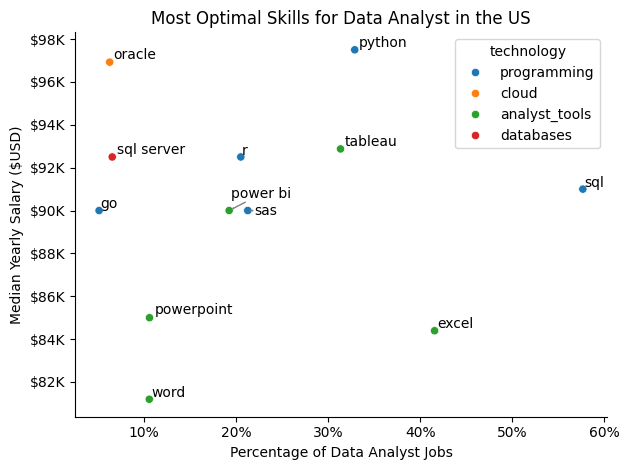

In [203]:
#df_DA_US_plot.plot(kind="scatter", x = "skill_percent", y = "median_salary", color = "brown")
sns.scatterplot(data = df_DA_US_plot, x = "skill_percent", y = "median_salary", hue = "technology")
sns.despine()

texts = []
for i, txt in enumerate(df_DA_skills_high_demand_US.index):
  texts.append(plt.text(df_DA_skills_high_demand_US["skill_percent"].iloc[i], df_DA_skills_high_demand_US["median_salary"].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray'))

plt.title("Most Optimal Skills for Data Analyst in the US")
plt.xlabel("Percentage of Data Analyst Jobs")
plt.ylabel("Median Yearly Salary ($USD)")


plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y/1000)}K"))
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals = 0))

plt.tight_layout()
plt.show()

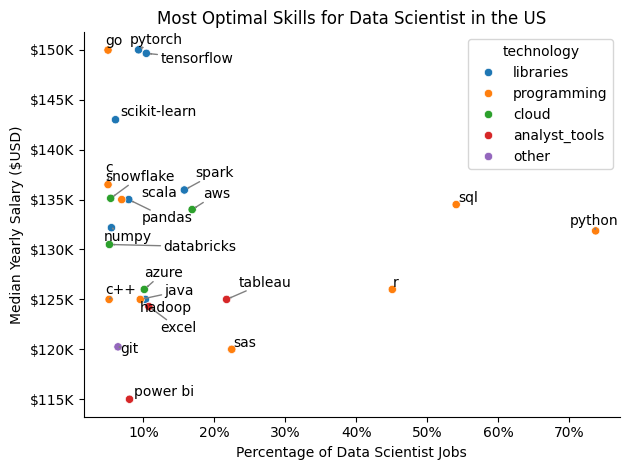

In [204]:
#df_DS_US_plot.plot(kind="scatter", x = "skill_percent", y = "median_salary", color = "brown")
sns.scatterplot(data = df_DS_US_plot, x = "skill_percent", y = "median_salary", hue = "technology")
sns.despine()

texts = []
for i, txt in enumerate(df_DS_skills_high_demand_US.index):
  texts.append(plt.text(df_DS_skills_high_demand_US["skill_percent"].iloc[i], df_DS_skills_high_demand_US["median_salary"].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray'))

plt.title("Most Optimal Skills for Data Scientist in the US")
plt.xlabel("Percentage of Data Scientist Jobs")
plt.ylabel("Median Yearly Salary ($USD)")


plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y/1000)}K"))
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals = 0))

plt.tight_layout()
plt.show()

In [205]:
df_DA_nonUS = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()
df_DA_nonUS = df_DA_nonUS.dropna(subset = ["salary_year_avg"])
df_DS_nonUS = df[(df["job_title_short"] == "Data Scientist") & (df["job_country"] == "United States")].copy()
df_DS_nonUS = df_DS_nonUS.dropna(subset = ["salary_year_avg"])

df_DA_nonUS_exploded = df_DA_nonUS.explode("job_skills")
df_DS_nonUS_exploded = df_DS_nonUS.explode("job_skills")

df_DA_skills_nonUS = df_DA_nonUS_exploded.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by = "median", ascending = False)
df_DA_skills_nonUS = df_DA_skills_nonUS.rename(columns={"count": "skill_count", "median": "median_salary"})
DA_job_count_nonUS = len(df_DA_nonUS)
df_DA_skills_nonUS["skill_percent"] = df_DA_skills_nonUS["skill_count"] / DA_job_count_nonUS * 100
skill_percent = 5
df_DA_skills_high_demand_nonUS = df_DA_skills_nonUS[df_DA_skills_nonUS["skill_percent"] > skill_percent]

df_DS_skills_nonUS = df_DS_nonUS_exploded.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by = "median", ascending = False)
df_DS_skills_nonUS = df_DS_skills_nonUS.rename(columns={"count": "skill_count", "median": "median_salary"})
DS_job_count_nonUS = len(df_DS_nonUS)
df_DS_skills_nonUS["skill_percent"] = df_DS_skills_nonUS["skill_count"] / DS_job_count_nonUS * 100
#skill_percent = 5
df_DS_skills_high_demand_nonUS = df_DS_skills_nonUS[df_DS_skills_nonUS["skill_percent"] > skill_percent]

In [206]:
df_DA_nonUS_plot = df_DA_skills_high_demand_nonUS.merge(df_technology, left_on = "job_skills", right_on = "skills")

df_DS_nonUS_plot = df_DS_skills_high_demand_nonUS.merge(df_technology, left_on = "job_skills", right_on = "skills")

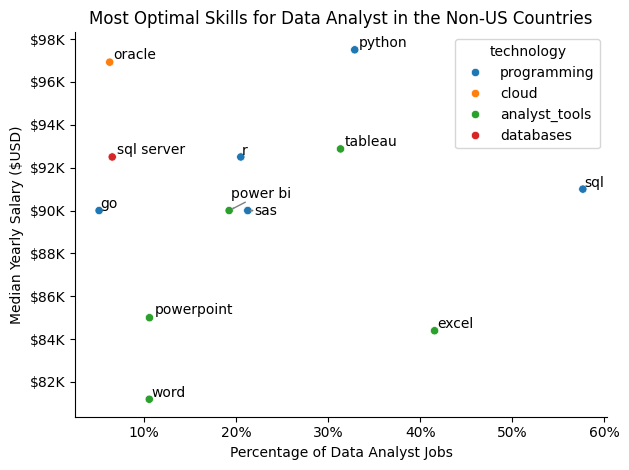

In [207]:
sns.scatterplot(data = df_DA_nonUS_plot, x = "skill_percent", y = "median_salary", hue = "technology")
sns.despine()

texts = []
for i, txt in enumerate(df_DA_skills_high_demand_nonUS.index):
  texts.append(plt.text(df_DA_skills_high_demand_nonUS["skill_percent"].iloc[i], df_DA_skills_high_demand_nonUS["median_salary"].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray'))

plt.title("Most Optimal Skills for Data Analyst in the Non-US Countries")
plt.xlabel("Percentage of Data Analyst Jobs")
plt.ylabel("Median Yearly Salary ($USD)")


plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y/1000)}K"))
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals = 0))

plt.tight_layout()
plt.show()

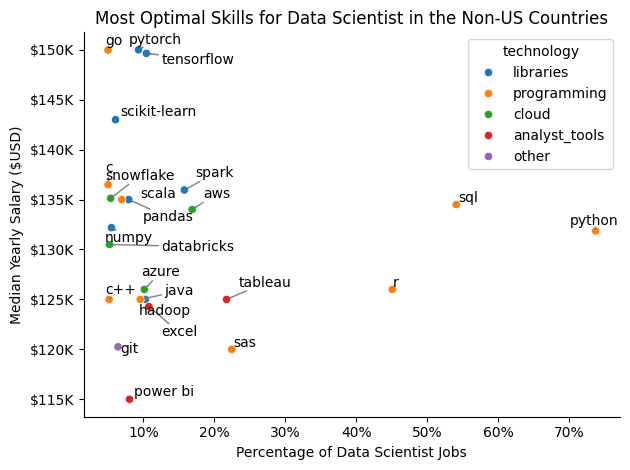

In [208]:
sns.scatterplot(data = df_DS_nonUS_plot, x = "skill_percent", y = "median_salary", hue = "technology")
sns.despine()

texts = []
for i, txt in enumerate(df_DS_skills_high_demand_nonUS.index):
  texts.append(plt.text(df_DS_skills_high_demand_nonUS["skill_percent"].iloc[i], df_DS_skills_high_demand_nonUS["median_salary"].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray'))

plt.title("Most Optimal Skills for Data Scientist in the Non-US Countries")
plt.xlabel("Percentage of Data Scientist Jobs")
plt.ylabel("Median Yearly Salary ($USD)")


plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y/1000)}K"))
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals = 0))

plt.tight_layout()
plt.show()